Radhika Puri

CPSC 393 - Machine Learning FALL 2025

Assignment 1

22 September 2025

In [ ]:
#to upload files from drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#imports

import numpy as np
import pandas as pd
from sklearn import datasets

from plotnine import *
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, mean_squared_error, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [ ]:
#data import
data = pd.read_csv('/content/drive/MyDrive/ML/assignment_01_data (1).csv')
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y
0,-0.604285,-0.610629,0.026014,0.019710,0.406532,0.678796,0.524360,0.404739,B
1,-0.111772,-1.125178,0.744157,0.078315,0.088176,0.891009,0.018460,0.536511,B
2,-0.916802,1.965494,0.150022,0.388770,0.179276,0.064449,0.159279,0.951204,B
3,-0.280479,0.920669,0.208949,0.940153,0.854437,0.688172,0.365126,0.985259,A
4,1.856025,1.043214,0.167088,0.207002,0.979049,0.641019,0.628764,0.045912,B


          X1        X2        X3        X4        X5        X6        X7  \
X1  1.000000 -0.162925  0.053404  0.048797  0.064429 -0.030689 -0.271790   
X2 -0.162925  1.000000  0.063820  0.176044  0.037858 -0.059990  0.178142   
X3  0.053404  0.063820  1.000000 -0.007330  0.028529 -0.074335 -0.107514   
X4  0.048797  0.176044 -0.007330  1.000000  0.160035  0.028746  0.026834   
X5  0.064429  0.037858  0.028529  0.160035  1.000000 -0.054253  0.022389   
X6 -0.030689 -0.059990 -0.074335  0.028746 -0.054253  1.000000 -0.129064   
X7 -0.271790  0.178142 -0.107514  0.026834  0.022389 -0.129064  1.000000   
X8 -0.004266 -0.020490 -0.013038  0.083458 -0.073225  0.021826 -0.016308   

          X8  
X1 -0.004266  
X2 -0.020490  
X3 -0.013038  
X4  0.083458  
X5 -0.073225  
X6  0.021826  
X7 -0.016308  
X8  1.000000  


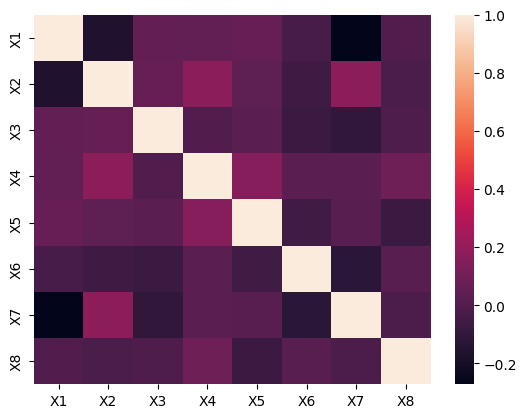

In [ ]:
#lets look at data coorelation matrix
pred = data.filter(regex = "X").columns
corr_matrix = data[pred].corr()
print(corr_matrix)

#coorelation heatmap
coor_map = sns.heatmap(corr_matrix);

In [ ]:
#preprocessing and train-test split
pred = data.filter(regex = "X").columns
X = data[pred]
y = data['Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 522)

#make column transformer to z-score
pre = StandardScaler()

Best Kernel from Gridsearch:  rbf
Best C from Gridsearch:  50
Best Gamma from Gridsearch:  0.01
Train Accuracy: 0.78875
Test Accuracy: 0.755
Train ROC/AUC: 0.8582604366688001
Test ROC/AUC: 0.8349096258932325
Test Confusion Matrix:
 [[ 48  30]
 [ 19 103]]


<Figure size 500x500 with 0 Axes>

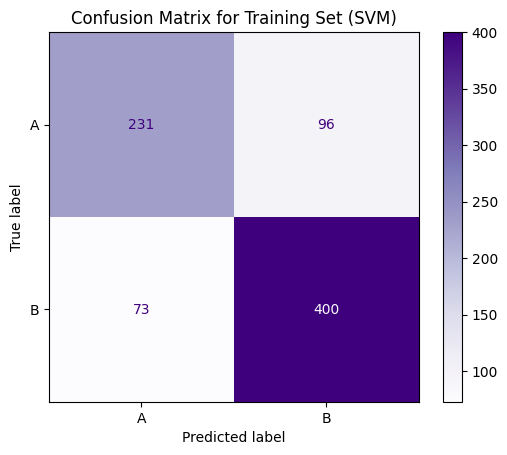

<Figure size 500x500 with 0 Axes>

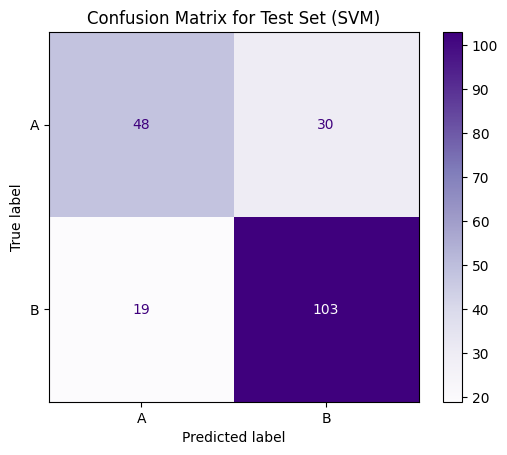

In [ ]:
#SVM model
SVM = SVC(probability = True)

#pipeline
pipeSVM = Pipeline([
    ('pre', pre),
    ('model', SVM)
])

#gridSearch to choose kernel, C, and Gamma
parameters = {'model__kernel':('linear', 'rbf'),
              'model__C':[0.001, 0.01, 1, 5, 25, 50],
              'model__gamma':[0.001,0.01, 0.1, 0.5, 1,2,5]}

grid = GridSearchCV(pipeSVM, parameters, scoring = 'accuracy', refit = True, cv = 5, verbose=0)
grid.fit(X_train, y_train)

print("Best Kernel from Gridsearch: ", grid.best_estimator_.get_params()["model__kernel"])
print("Best C from Gridsearch: ", grid.best_estimator_.get_params()["model__C"])
print("Best Gamma from Gridsearch: ", grid.best_estimator_.get_params()["model__gamma"])

#prediction and resultts
y_pred_train = grid.best_estimator_.predict(X_train)
y_pred_test = grid.best_estimator_.predict(X_test)

y_pred_train_prob = grid.best_estimator_.predict_proba(X_train)[:,1]
y_pred_test_prob = grid.best_estimator_.predict_proba(X_test)[:,1]

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("Train ROC/AUC:", roc_auc_score(y_train, y_pred_train_prob))
print("Test ROC/AUC:", roc_auc_score(y_test, y_pred_test_prob))

print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))


# Confusion Matrix for training set
plt.figure(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(grid, X_train, y_train, cmap=plt.cm.Purples, normalize=None)
plt.title('Confusion Matrix for Training Set (SVM)')
plt.show()

# Confusion Matrix for test set
plt.figure(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test, cmap=plt.cm.Purples, normalize=None)
plt.title('Confusion Matrix for Test Set (SVM)')
plt.show()

Train Accuracy: 0.7575
Test Accuracy: 0.78
Train ROC/AUC: 0.8395432886578609
Test ROC/AUC: 0.8667507356031946


<Figure size 700x700 with 0 Axes>

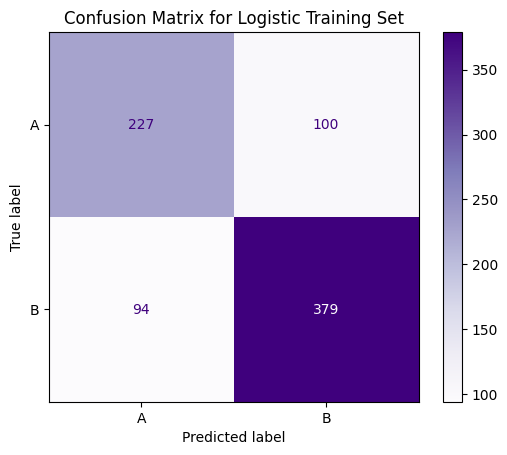

<Figure size 700x700 with 0 Axes>

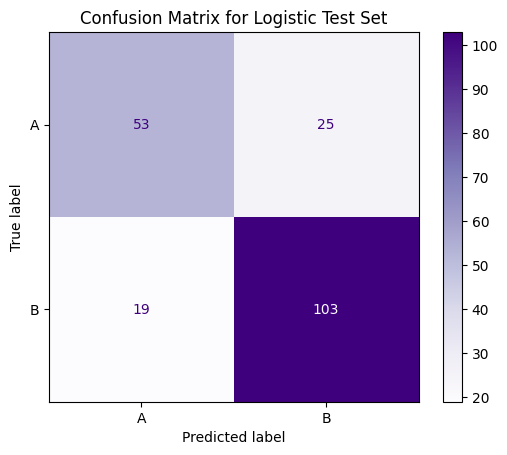

In [ ]:
#logistic Regression on the same data

# logit model
lr = LogisticRegression()

# Pipeline
pipe = Pipeline([
    ('pre', pre),
    ('logisticregression', lr)
])

pipe.fit(X_train, y_train)

y_pred_train = pipe.predict(X_train)
y_pred_test = pipe.predict(X_test)

# Accuracy and ROC/AUC scores
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

y_pred_train_prob = pipe.predict_proba(X_train)[:, 1]
y_pred_test_prob  = pipe.predict_proba(X_test)[:, 1]

print("Train ROC/AUC:", roc_auc_score(y_train, y_pred_train_prob))
print("Test ROC/AUC:", roc_auc_score(y_test, y_pred_test_prob))

# Plot for the training set
plt.figure(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(pipe, X_train, y_train, cmap=plt.cm.Purples, normalize=None)
plt.title('Confusion Matrix for Logistic Training Set')
plt.show()

# Plot for the test set
plt.figure(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test, cmap=plt.cm.Purples, normalize=None)
plt.title('Confusion Matrix for Logistic Test Set')
plt.show()

GridSearchCV chose:  1
Train Accuracy: 1.0
Test Accuracy: 0.705
Train ROC/AUC: 1.0
Test ROC/AUC: 0.6865279529213956


<Figure size 700x700 with 0 Axes>

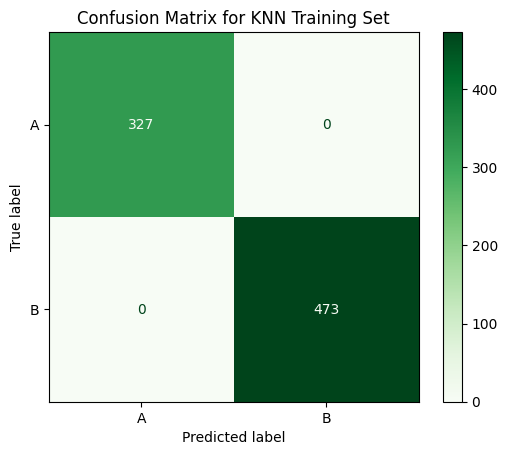

<Figure size 700x700 with 0 Axes>

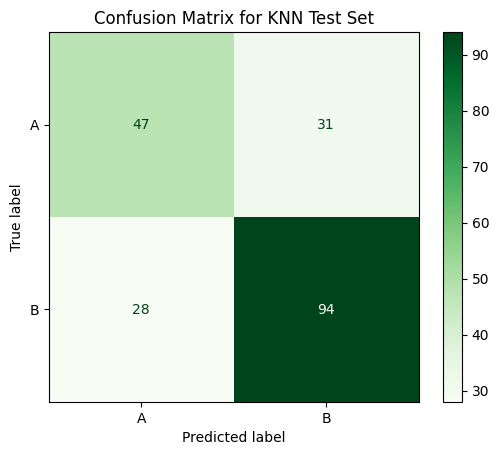

In [ ]:
#knn Model on the same data

# create model
knn = KNeighborsClassifier()

pipe = Pipeline([("pre", pre), ("model", knn)])

# choose potential values of k
ks = {"model__n_neighbors": [1,2,5,10,20]}

# use grid search to find best parameters
grid = GridSearchCV(pipe, ks, scoring = "precision", cv = 5, refit = True)

grid.fit(X_train, y_train)

print("GridSearchCV chose: ", grid.best_estimator_.get_params()["model__n_neighbors"])

# Predict
y_pred_train = grid.predict(X_train)
y_pred_test = grid.predict(X_test)

y_pred_train_prob = grid.predict_proba(X_train)[:,1]
y_pred_test_prob = grid.predict_proba(X_test)[:,1]

# Accuracy and ROC/AUC
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

y_pred_train_prob = grid.best_estimator_.predict_proba(X_train)[:, 1]
y_pred_test_prob  = grid.best_estimator_.predict_proba(X_test)[:, 1]

print("Train ROC/AUC:", roc_auc_score(y_train, y_pred_train_prob))
print("Test ROC/AUC:", roc_auc_score(y_test, y_pred_test_prob))

# Plot for training set
plt.figure(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(grid, X_train, y_train, cmap=plt.cm.Greens, normalize=None)
plt.title('Confusion Matrix for KNN Training Set')
plt.show()

# Plot for test set
plt.figure(figsize=(7, 7))
ConfusionMatrixDisplay.from_estimator(grid, X_test, y_test, cmap=plt.cm.Greens, normalize=None)
plt.title('Confusion Matrix for KNN Test Set')
plt.show()